# Classifying galaxies and quasars in the SDSS catalogue

#### Tasks

- Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

#### Ideas
- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?



In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
names = np.genfromtxt('../solutions/galaxyquasar.csv', delimiter=',', names=True, usecols=(0,1,2,3,4,6), dtype=float, comments='#')
names = names.dtype.names
data = np.genfromtxt('../solutions/galaxyquasar.csv', delimiter=',', skip_header=1, usecols=(0,1,2,3,4,6),dtype=float,comments='#')
l = np.genfromtxt('../solutions/galaxyquasar.csv', delimiter=',', skip_header=1, usecols=5, dtype=str)

In [4]:
d = dict(zip(names, data.T))

In [5]:
sub_colors = ['ug', 'gr', 'ri', 'iz']
for n in sub_colors:
    d[n] = d[n[0]] - d[n[1]]

labels = []
for i in range(len(l)):
    if l[i] == 'QSO': 
        labels.append(1)
    else: labels.append(0)
        
d['lab'] = labels

In [6]:
X = np.array([d['ug'], d['gr'], d['ri'], d['iz']]).T
y = np.array([d['lab']]).T

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.3, random_state = 42)
y_train = y_train.ravel()
y_val = y_val.ravel()
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(35000, 4) (15000, 4) (35000,) (15000,)


## Gaussian Naive Bayes

In [9]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
gnb_prob = gnb.predict_proba(X_val)
fpr, tpr, thresh = roc_curve(y_val, gnb_prob[:,1])

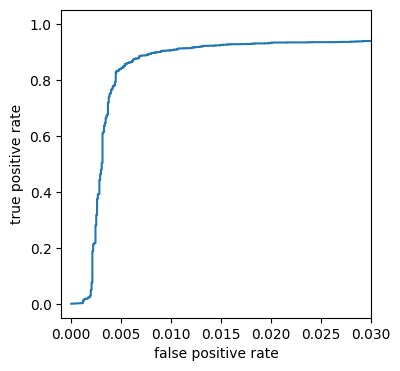

In [10]:
fig = plt.figure(figsize=(4,4))
plt.plot(fpr, tpr)
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.xlim(-0.001, 0.03)
plt.show()

Let's fit the GNB model using subsets of colors and see which one works best.

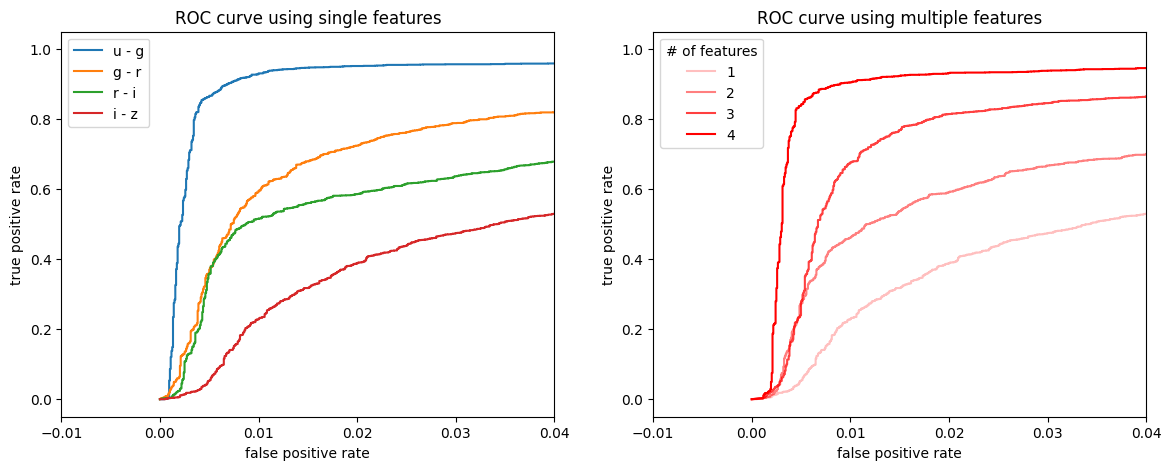

In [11]:
fig = plt.figure(figsize = (14, 5))

ax = fig.add_subplot(121)
for i in range(4):
    gnb.fit(X_train[:, i][:, None], y_train)
    gnb_prob = gnb.predict_proba(X_val[:, i][:, None])[:,1]
    fpr, tpr, thresh = roc_curve(y_val, gnb_prob)
    ax.plot(fpr, tpr, label = sub_colors[i][0] + ' - ' + sub_colors[i][1])
ax.set(xlabel='false positive rate', ylabel = 'true positive rate', title = 'ROC curve using single features', xlim = (-0.01, 0.04))
ax.legend()

ax = fig.add_subplot(122)
for i in range(1, 5):
    a = i / 4
    gnb.fit(X_train[:, 4-i:], y_train)
    gnb_prob = gnb.predict_proba(X_val[:, 4-i:])[:,1]
    fpr, tpr, thresh = roc_curve(y_val, gnb_prob)
    ax.plot(fpr, tpr, label = i, c = 'red', alpha = a)
ax.set(xlabel='false positive rate', ylabel = 'true positive rate', title = 'ROC curve using multiple features', xlim = (-0.01, 0.04))

ax.legend(title = '# of features')
plt.show()

Both plots seem to indicate that we can analyse the system using only the u - g line. 

More in detail, the plot on the left shows that the best performance is achieved with the u-g line. The plot on the right instead shows that performance improves everytime we add a feature and improves dramatically by adding the u-g line (5 elements).

Can we observe the two distinct classes in the u-g line?

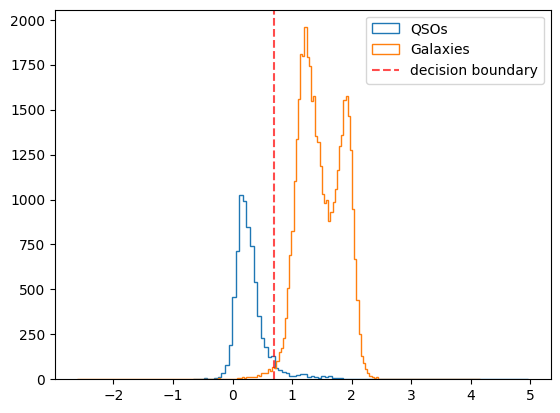

In [12]:
gnb.fit(X_train[:, 0][:, None], y_train)

#computing decision boundary
x_bounds = np.linspace(-2,4, 200)
y_bounds = gnb.predict(x_bounds.reshape(-1,1))
dec_boundary = np.mean([max(x_bounds[y_bounds ==1]), min(x_bounds[y_bounds==0])])

y_arr = np.array(y)
y_arr = y_arr.reshape(1,len(y))[0]
plt.hist(X[y_arr==1, 0], bins='scott', histtype='step', label='QSOs')
plt.hist(X[y_arr==0, 0],bins='scott',  histtype='step', label='Galaxies')
plt.axvline(dec_boundary, label='decision boundary', ls='dashed', c='r', alpha = 0.7)
plt.legend()
plt.show()

In [13]:
import corner

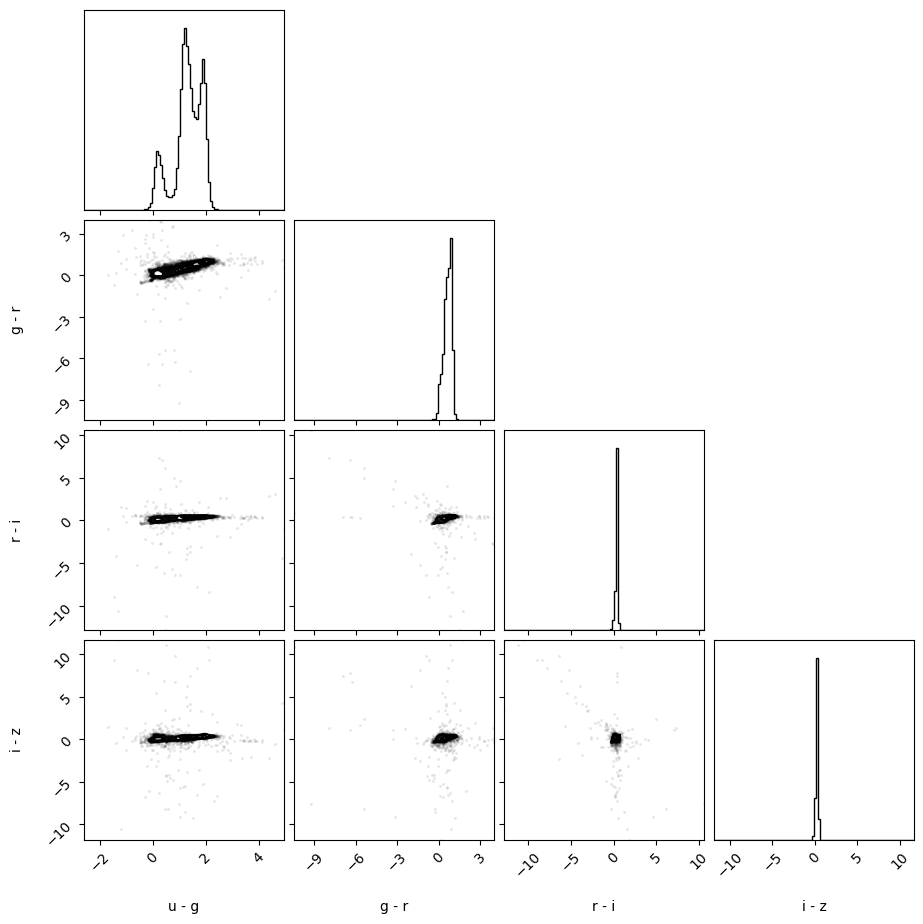

In [14]:
corner.corner(X, bins=100, labels=['u - g', 'g - r', 'r - i', 'i - z'])
plt.show()

Seems reasonable, the bimodality is only explicit for the u-g feature. However, the (u-g) and (g-r) feature seem to be somewhat correlated, which could negate the independent assumption behind Gaussian NB. LDA and QDA instead assume a joint Gaussian distribution for the features and include the correlation matrix, so they might be more indicated for this set.


Let's now check the results with different classification algorithms:

## Linear Discriminant Analysis

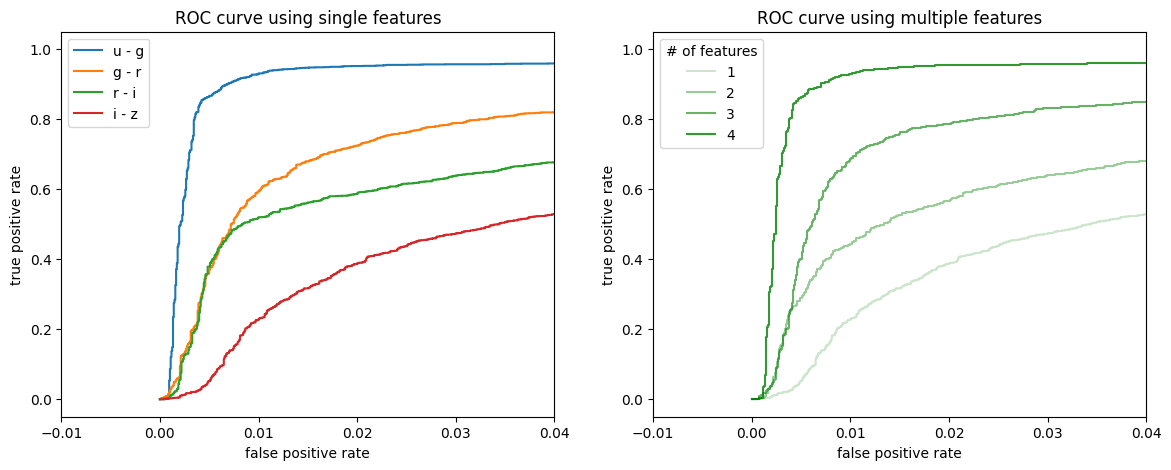

In [15]:
lda = LDA()
fig = plt.figure(figsize = (14, 5))

ax = fig.add_subplot(121)
for i in range(4):
    lda.fit(X_train[:, i][:, None], y_train)
    lda_prob = lda.predict_proba(X_val[:, i][:, None])[:, 1]
    fpr, tpr, thresh = roc_curve(y_val, lda_prob)
    ax.plot(fpr, tpr, label = sub_colors[i][0] + ' - ' + sub_colors[i][1])
ax.set(xlabel='false positive rate', ylabel = 'true positive rate', title = 'ROC curve using single features', xlim = (-0.01, 0.04))
ax.legend()

ax = fig.add_subplot(122)
for i in range(1, 5):
    a= i / 5
    lda.fit(X_train[:, 4-i:], y_train)
    lda_prob = lda.predict_proba(X_val[:, 4-i:])[:,1]
    fpr, tpr, thresh = roc_curve(y_val, lda_prob)
    ax.plot(fpr, tpr, label = i, c='green', alpha =a)
ax.set(xlabel='false positive rate', ylabel = 'true positive rate', title = 'ROC curve using multiple features', xlim = (-0.01, 0.04))
ax.legend(title = '# of features')

plt.show()

## Quadraric Discriminant Analysis

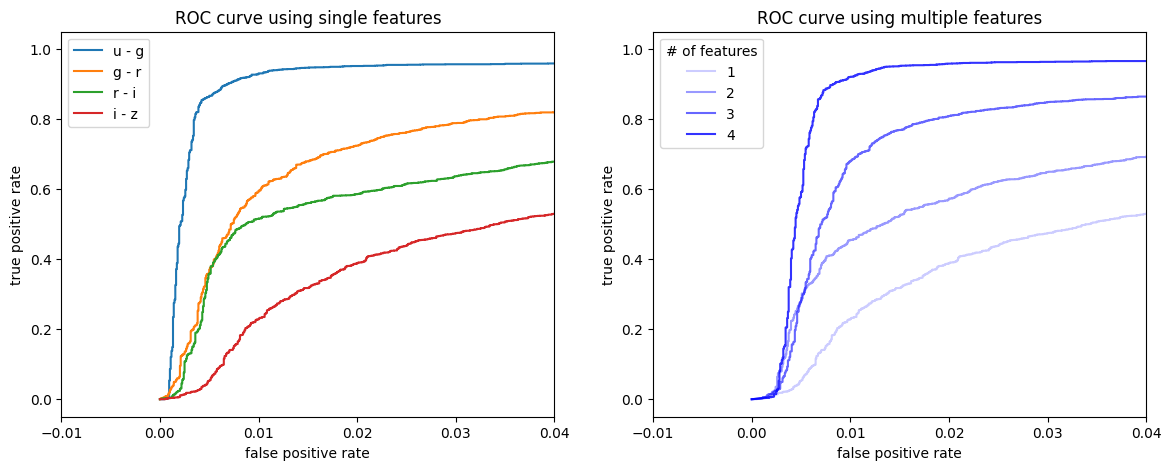

In [16]:
qda = QDA()
fig = plt.figure(figsize = (14, 5))

ax = fig.add_subplot(121)
for i in range(4):
    qda.fit(X_train[:, i][:, None], y_train)
    qda_prob = qda.predict_proba(X_val[:, i][:, None])[:, 1]
    fpr, tpr, thresh = roc_curve(y_val, qda_prob)
    ax.plot(fpr, tpr, label = sub_colors[i][0] + ' - ' + sub_colors[i][1])
ax.set(xlabel='false positive rate', ylabel = 'true positive rate', title = 'ROC curve using single features', xlim = (-0.01, 0.04))
ax.legend()

ax = fig.add_subplot(122)
for i in range(1, 5):
    a = i / 5
    qda.fit(X_train[:, 4-i:], y_train)
    qda_prob = qda.predict_proba(X_val[:, 4-i:])[:,1]
    fpr, tpr, thresh = roc_curve(y_val, qda_prob)
    ax.plot(fpr, tpr, label = i, color = 'blue', alpha = a)
ax.set(xlabel='false positive rate', ylabel = 'true positive rate', title = 'ROC curve using multiple features', xlim = (-0.01, 0.04))
ax.legend(title = '# of features')

plt.show()

All three methods seems to agree that the u-g feature is the most important one. What is the best model overall?

In [17]:
from astroML.classification import GMMBayes

In [51]:
def compute_ROC(X_train, y_train, X_val, y_val, clf_name):
    if clf_name=='GNB':
        clf=GaussianNB()
    elif clf_name=='LDA':
        clf=LDA()
    elif clf_name=='QDA':
        clf=QDA()
    elif clf_name=='GMM':
        clf=GMMBayes(n_components=3)
        
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_val)[:,1]
    fpr, tpr, thresh = roc_curve(y_val, y_prob)
    return fpr, tpr

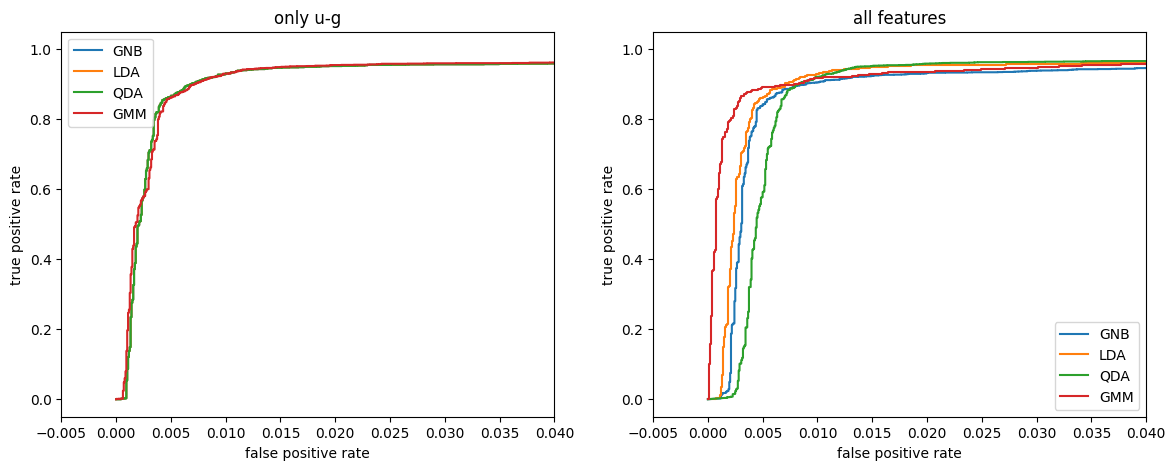

In [55]:
fig = plt.figure(figsize = (14, 5))

#only on u-g line -----------
ax = fig.add_subplot(121)
ax.set(xlabel='false positive rate', ylabel = 'true positive rate', title = 'only u-g', xlim = (-0.005, 0.04))
ug_train = X_train[:,0].reshape(-1,1)
ug_val = X_val[:,0].reshape(-1,1)
clf=['GNB', 'LDA', 'QDA', 'GMM']
for c in clf:
    fpr, tpr = compute_ROC(ug_train, y_train, ug_val, y_val, c)
    ax.plot(fpr, tpr, label=c)

ax.legend()
#on all features -----------

ax = fig.add_subplot(122)
ax.set(xlabel='false positive rate', ylabel = 'true positive rate', title = 'all features', xlim = (-0.005, 0.04))
for c in clf:
    fpr, tpr = compute_ROC(X_train, y_train, X_val, y_val, c)
    ax.plot(fpr, tpr, label=c)
ax.legend()
plt.show()

In the plot on the left GNB, LDA and QDA overlap: QDA and GNB are the exact same method if you only have 1 feature = no correlation. If we only had this feature, GNB would suffice.
The plot on the right instead shows that considering all the features GMM performs the best.

 Finally let's try a quick run with K-Nearest Neighbors.

## K-Nearest Neighbors

In [56]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

from tqdm import tqdm

In [57]:
#cross validate on # of neighbors
k_try = np.linspace(1, 15, 15, dtype = int)
accuracy = []
for k in tqdm(k_try):
    knc = KNeighborsClassifier(n_neighbors = k)
    y_cv = cross_val_predict(knc, X, y.ravel())
    accuracy.append(accuracy_score(y.ravel(),y_cv))

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:07<00:00,  1.88it/s]


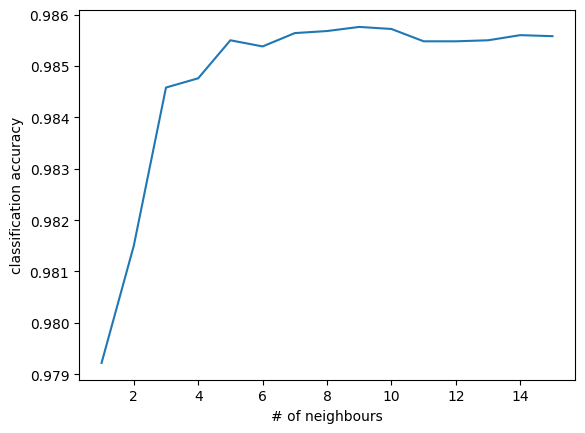

In [58]:
plt.plot(k_try, accuracy)
plt.xlabel('# of neighbours')
plt.ylabel('classification accuracy')
plt.show()

In [59]:
k_best = k_try[np.argmax(accuracy)]
print('Maximum accuracy for ', k_best, ' neighbours')

Maximum accuracy for  9  neighbours


In [60]:
from sklearn import metrics 

In [61]:
knc = KNeighborsClassifier(n_neighbors=k_best)
knc.fit(X_train[:, 0][:, None], y_train)

y_pred = knc.predict(X_val[:, 0][:, None])
print("accuracy:", metrics.accuracy_score(y_val, y_pred))
print("precision:", metrics.precision_score(y_val, y_pred))
print("recall:", metrics.recall_score(y_val, y_pred))

accuracy: 0.9804666666666667
precision: 0.9404927940492794
recall: 0.9245886654478976


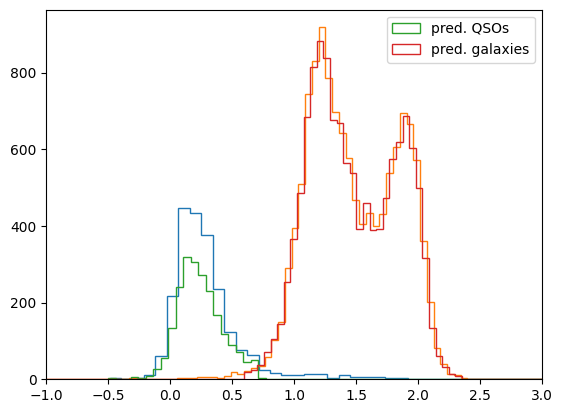

In [62]:
plt.hist(X_val[y_val==1, 0], bins = 'scott', histtype='step')
plt.hist(X_val[y_val==0, 0], bins = 'scott', histtype='step')

plt.hist(X_val[y_pred==1, 0], bins = 'scott', histtype='step', label ='pred. QSOs')
plt.hist(X_val[y_pred==0, 0], bins = 'scott', histtype='step', label = 'pred. galaxies')

plt.legend()
plt.xlim(-1, 3)
plt.show()